In [1]:
#first I uploaded the file train_snli.text on my google drive for email ID: Akshatshrinate.bt21ece@pec.edu.in
#now from my google drive I will import the file which needs that I mount my drive over the colab file
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#Now I copied the file path in a variable and using that I am opening the file
#Once the file is opened in read mode, I want that the lines are stored in a list with variable name data

file_path = '/content/drive/My Drive/train_snli.txt'
with open(file_path, 'r') as file:
    training_data = file.readlines()
    print(training_data[:5])

#now the issue is that the data is not in tabular form
#there is text and numeric based data with two '\t' and the third with '\n' signifying there are 3 columns for each row.

['A person on a horse jumps over a broken down airplane.\tA person is at a diner, ordering an omelette.\t0\n', 'A person on a horse jumps over a broken down airplane.\tA person is outdoors, on a horse.\t1\n', 'Children smiling and waving at camera\tThere are children present\t1\n', 'Children smiling and waving at camera\tThe kids are frowning\t0\n', 'A boy is jumping on skateboard in the middle of a red bridge.\tThe boy skates down the sidewalk.\t0\n']


In [3]:
#Installing/importing some of the basic dependancies that will be used
import re
import csv
import nltk
from tqdm import tqdm
from tqdm.notebook import tqdm
import string

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [4]:
#to convert the dataset into tabular form, a csv file is created called training data
#the data set contains three columns per row, one is source text, the other is copied text, and the third is a label or classification
#The classification is either 1 or 0 depending on it is copied or not

with open('training_data.csv', 'w', newline='') as csvfile:
    filenames = ['source_text', 'plag_text', 'classification']
    writer = csv.DictWriter(csvfile, fieldnames=filenames)
    writer.writeheader()

    for line in tqdm(training_data):
        parts = line.strip().split('\t')
        source_text = parts[0]
        plag_text = parts[1]
        classification = int(parts[2])

        writer.writerow({
            'source_text': source_text,
            'plag_text': plag_text,
            'classification': classification
        })

print('CSV file created successfully...')

  0%|          | 0/367373 [00:00<?, ?it/s]

CSV file created successfully...


**The Dataset has been Created. The next steps involve checking the dataset for null and Duplicate values and getting rid of these redundancies.**

In [5]:
dataset = pd.read_csv("training_data.csv")
dataset.head()

,source_text,plag_text,classification
0,A person on a horse jumps over a broken down a...,"A person is at a diner, ordering an omelette.",0
1,A person on a horse jumps over a broken down a...,"A person is outdoors, on a horse.",1
2,Children smiling and waving at camera,There are children present,1
3,Children smiling and waving at camera,The kids are frowning,0
4,A boy is jumping on skateboard in the middle o...,The boy skates down the sidewalk.,0


In [6]:
def preprocess_text(text):
    if isinstance(text, str):
        text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation (like commas)
        text = text.lower()  # Convert to lowercase
        return text
    return ""
dataset['source_text'] = dataset['source_text'].apply(preprocess_text)
dataset['plag_text'] = dataset['plag_text'].apply(preprocess_text)
dataset.head()

,source_text,plag_text,classification
0,a person on a horse jumps over a broken down a...,a person is at a diner ordering an omelette,0
1,a person on a horse jumps over a broken down a...,a person is outdoors on a horse,1
2,children smiling and waving at camera,there are children present,1
3,children smiling and waving at camera,the kids are frowning,0
4,a boy is jumping on skateboard in the middle o...,the boy skates down the sidewalk,0


In [7]:
dataset.shape

(367373, 3)

In [8]:
# check for null values
print("Null values:", dataset.isnull().sum())

Null values: source_text       0
plag_text         0
classification    0
dtype: int64


In [9]:
# remove null values
dataset.dropna(inplace=True)

In [10]:
print("Null values after removing:", dataset.isnull().sum())

Null values after removing: source_text       0
plag_text         0
classification    0
dtype: int64


In [11]:
# check for duplicates
print("Duplicates:", dataset.duplicated().sum())

Duplicates: 606


In [12]:
# remove all the duplicates
dataset.drop_duplicates(inplace=True)


In [13]:
print("Duplicates after removing:", dataset.duplicated().sum())

Duplicates after removing: 0


In [14]:
#I just checked the final shape of the dataset which gives me an idea of the number of rows
dataset.shape

(366767, 3)

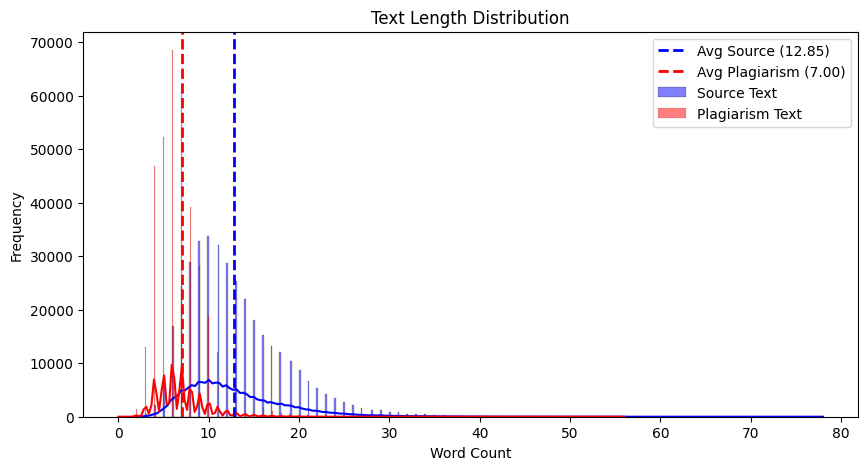

In [15]:
# To start understanding the two columns: the source_text and the plag_text
#I went through the process of creating a Text Length Distribution comparing word counts between source text and plagiarized text samples
#this is done to understand how the samples are different from each other and what model is suitable for building the plag checker

# Calculate source and plagiarism text lengths
dataset['source_text_length'] = dataset['source_text'].apply(lambda x: len(x.split()))
dataset['plag_text_length'] = dataset['plag_text'].apply(lambda x: len(x.split()))

#The histogram plotting
plt.figure(figsize=(10, 5))
sns.histplot(dataset['source_text_length'], color='blue', label='Source Text', kde=True)
sns.histplot(dataset['plag_text_length'], color='red', label='Plagiarism Text', kde=True)

# Calculate averages
avg_source_text_length = dataset['source_text_length'].mean()
avg_plag_text_length = dataset['plag_text_length'].mean()

# average lines for each were added in the graph
plt.axvline(avg_source_text_length, color='blue', linestyle='dashed', linewidth=2, label=f'Avg Source ({avg_source_text_length:.2f})')
plt.axvline(avg_plag_text_length, color='red', linestyle='dashed', linewidth=2, label=f'Avg Plagiarism ({avg_plag_text_length:.2f})')

# Presentation of the graph
plt.title('Text Length Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [47]:
#Cosine similarity is a measure of similarity between two non-zero vectors, by measuring the cosine of the angle between them.
#This value lies between between 0 and 1, where 1 indicates that the two texts are identical, and 0 indicates no similarity.
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
# Limit to first 15000 rows
num_rows_to_process = 15000
dataset_subset = dataset.head(num_rows_to_process)

# Initialize CountVectorizer
vectorizer = CountVectorizer()

# Variable to accumulate total cosine similarity
total_cos_sim = 0
num_rows = len(dataset_subset)

# Loop through each row in the dataset subset (first 2000 rows)
for index, row in dataset_subset.iterrows():
    source_text = row['source_text']
    plag_text = row['plag_text']

    # Vectorize the texts
    vectors = vectorizer.fit_transform([source_text, plag_text])

    # Calculate cosine similarity between the two vectors
    cos_sim = cosine_similarity(vectors[0], vectors[1])

    # Add cosine similarity to total
    total_cos_sim += cos_sim[0][0]

# Calculate average cosine similarity
avg_cos_sim = total_cos_sim / num_rows

# Print the average cosine similarity
print(f"Average Cosine Similarity for first 15000 rows: {avg_cos_sim:.4f}")

Average Cosine Similarity for first 15000 rows: 0.3279


THe cosine similarity of 0.32 signifies that the two texts are not much similar

In [16]:
!pip install xgboost
import xgboost as xgb
print(xgb.__version__)

import pickle
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

!pip install tensorflow
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, Dense, LSTM, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

!pip install keras-tuner --quiet
import keras_tuner as kt



#further dependancies are installed

2.1.4


In [17]:
# Tokenization and padding
tokenizer = Tokenizer(oov_token='<OOV>')
tokenizer.fit_on_texts(dataset['source_text'] + ' ' + dataset['plag_text'])
X = tokenizer.texts_to_sequences(dataset['source_text'] + ' ' + dataset['plag_text'])
X = pad_sequences(X, maxlen=150)  # Cap sequence length to 150

y = dataset['classification']

# Splitting the dataset into 3 parts training, validation and testing
xtrain, xval_test, ytrain, yval_test = train_test_split(X, y, test_size=0.3, random_state=42)
xval, xtest, yval, ytest = train_test_split(xval_test, yval_test, test_size=0.5, random_state=42)

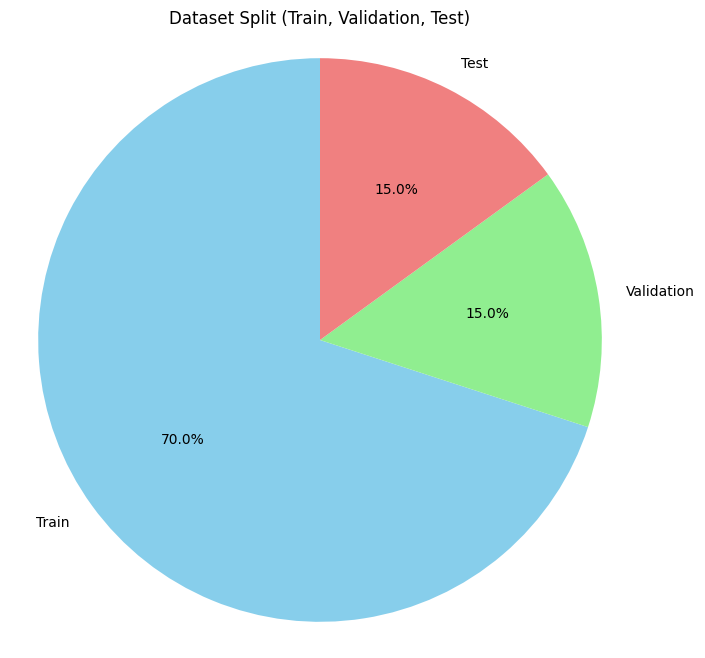

In [18]:
# Function to plot pie chart for vizualization of the three datasets
# Calculate the sizes of each split
train_size = len(xtrain) / len(dataset) * 100
val_size = len(xval) / len(dataset) * 100
test_size = len(xtest) / len(dataset) * 100

# Labels and sizes for pie chart
labels = ['Train', 'Validation', 'Test']
sizes = [train_size, val_size, test_size]
colors = ['skyblue', 'lightgreen', 'lightcoral']

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Dataset Split (Train, Validation, Test)')
plt.axis('equal')  # Equal aspect ratio ensures that pie chart is drawn as a circle.
plt.show()

In [19]:
# LSTM Model made for training the dataset
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 100

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    LSTM(128, return_sequences=True),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Early stopping
callback = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Train model
history = model.fit(xtrain, ytrain, epochs=3, batch_size=128, validation_data=(xval, yval), callbacks=[callback])

# Evaluation of the model
test_loss, test_acc = model.evaluate(xtest, ytest)
print(f"Test accuracy (LSTM): {test_acc}")

# Once this was done, I went on to save the model and tokenizer
model.save('lstm_model.h5')
with open('tokenizer.pkl', 'wb') as file:
    pickle.dump(tokenizer, file)

Epoch 1/3
2006/2006 ━━━━━━━━━━━━━━━━━━━━ 55s 25ms/step - accuracy: 0.7215 - loss: 0.5232 - val_accuracy: 0.7980 - val_loss: 0.4184
Epoch 2/3
2006/2006 ━━━━━━━━━━━━━━━━━━━━ 47s 23ms/step - accuracy: 0.8295 - loss: 0.3719 - val_accuracy: 0.8283 - val_loss: 0.3739
Epoch 3/3
2006/2006 ━━━━━━━━━━━━━━━━━━━━ 82s 23ms/step - accuracy: 0.8671 - loss: 0.3061 - val_accuracy: 0.8447 - val_loss: 0.3529
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8471 - loss: 0.3558


Test accuracy (LSTM): 0.8457721471786499


In [20]:
# Hyperparameters tuning with 4 parameters
def build_model(hp):
    model = Sequential()

    # 1st parameter: embedding_dim
    model.add(Embedding(input_dim=vocab_size, output_dim=hp.Choice('embedding_dim', [64, 100]), input_length=150))

    # 2nd parameter: lstm_units
    model.add(LSTM(units=hp.Choice('lstm_units', [64, 128])))

    # 3rd parameter: learning_rate
    lr = hp.Choice('learning_rate', [1e-3, 1e-4])

    # 4th parameter: dense_units
    model.add(Dense(units=hp.Choice('dense_units', [32, 64]), activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# Random search with just 1 trial of 2 epochs. I did this due to the compile time taken for more trials
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=1,
    executions_per_trial=1,
    overwrite=True,
    directory='tuner_dir',
    project_name='lstm_tuning_minimal'
)

# Search with EarlyStopping
tuner.search(
    xtrain, ytrain,
    epochs=2,
    validation_data=(xval, yval),
    callbacks=[EarlyStopping(monitor='val_loss', patience=1)]
)

# Evaluate best model
best_model = tuner.get_best_models(1)[0]
loss, acc = best_model.evaluate(xtest, ytest)
print(f"Final Test Accuracy: {acc:.4f}")

Trial 1 Complete [00h 03m 47s]
val_accuracy: 0.836480975151062

Best val_accuracy So Far: 0.836480975151062
Total elapsed time: 00h 03m 47s


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1720/1720 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8334 - loss: 0.3633
Final Test Accuracy: 0.8370


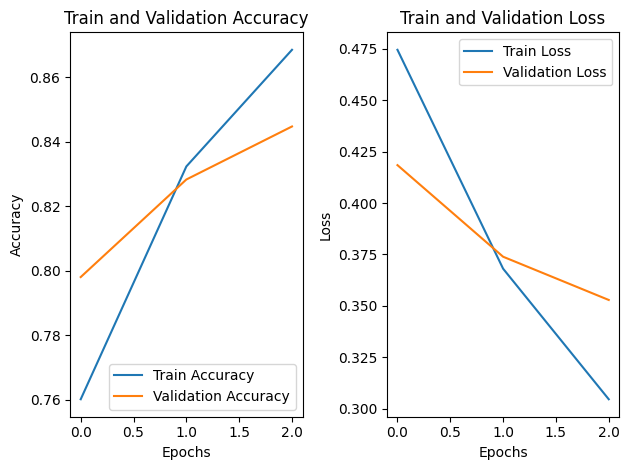

In [48]:
# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')  # Access 'accuracy' from history.history
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')  # Access 'val_accuracy' from history.history
plt.title('Train and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')  # Access 'loss' from history.history
plt.plot(history.history['val_loss'], label='Validation Loss')  # Access 'val_loss' from history.history
plt.title('Train and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


1720/1720 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
Final Model Accuracy on Test Set: 0.8370


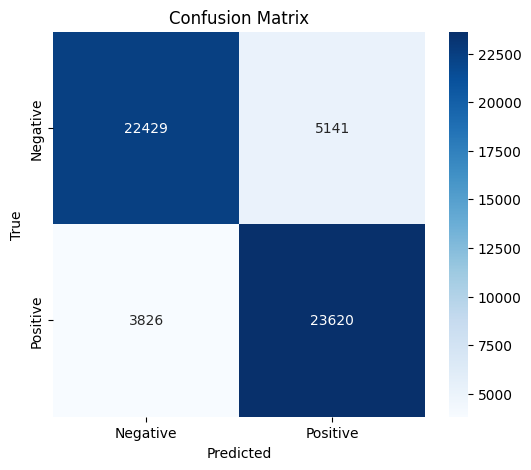


Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.81      0.83     27570
           1       0.82      0.86      0.84     27446

    accuracy                           0.84     55016
   macro avg       0.84      0.84      0.84     55016
weighted avg       0.84      0.84      0.84     55016



In [49]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# ====== Predict on Test Set ======
y_pred_final = best_model.predict(xtest)  # Replace final_model with best_model
y_pred_binary_final = (y_pred_final > 0.5).astype(int)

# ====== Final Test Accuracy ======
final_accuracy = accuracy_score(ytest, y_pred_binary_final)
print(f"Final Model Accuracy on Test Set: {final_accuracy:.4f}")

# ====== Confusion Matrix ======
cm = confusion_matrix(ytest, y_pred_binary_final)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ====== Classification Report ======
print("\nClassification Report:")
print(classification_report(ytest, y_pred_binary_final))

In [42]:
best_model.save('plagiarism_detector_model.keras')  # Save the model in .h5 format (Keras format)



In [50]:
# Load the saved model
from tensorflow.keras.models import load_model

best_model_loaded = load_model('plagiarism_detector_model.keras')
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# Predict using the loaded model
ytest_pred_probs = best_model_loaded.predict(xtest)  # Using xtest instead of dtest
ytest_pred_labels = (ytest_pred_probs > 0.5).astype(int)

# Check accuracy of the loaded model
accuracy_loaded = accuracy_score(ytest, ytest_pred_labels)
print(f"Loaded Model Accuracy on Test Set: {accuracy_loaded:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1720/1720 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step
Loaded Model Accuracy on Test Set: 0.8370


In [51]:
import random
# Get 5 random sample indices
random_indices = random.sample(range(len(xtest)), 5)

# Initialize a counter for correct predictions
correct_predictions = 0

# Loop through the random samples and print both actual and predicted values
for idx in random_indices:
    source_text = dataset.iloc[idx]['source_text']
    plag_text = dataset.iloc[idx]['plag_text']
    actual_label = dataset.iloc[idx]['classification']
    predicted_label = ytest_pred_labels[idx]

    # Print the source and plagiarized text along with actual and predicted labels
    print(f"Source Text: {source_text}")
    print(f"Plagiarized Text: {plag_text}")
    print(f"Actual Label: {actual_label}, Predicted Label: {predicted_label}")
    print("-" * 50)

    # Update the correct predictions counter
    if actual_label == predicted_label:
        correct_predictions += 1

# Print the number of correct predictions
print(f"\nCorrect Predictions: {correct_predictions} out of 5")

Source Text: two men are building a set
Plagiarized Text: the men are making a set
Actual Label: 1, Predicted Label: [1]
--------------------------------------------------
Source Text: a biker spins his bike in the air above the ground
Plagiarized Text: a guy is on a bike
Actual Label: 1, Predicted Label: [1]
--------------------------------------------------
Source Text: a man in a colorful shirt and glasses is playing guitar on stage
Plagiarized Text: the man is standing on a stage
Actual Label: 1, Predicted Label: [0]
--------------------------------------------------
Source Text: six people are sitting around an lshaped table surrounded by books and yarn
Plagiarized Text: people are jumping indoors
Actual Label: 0, Predicted Label: [1]
--------------------------------------------------
Source Text: two small dogs run across the green grass
Plagiarized Text: two little dogs run across the grass
Actual Label: 1, Predicted Label: [1]
--------------------------------------------------


In [ ]:
# an Accuracy 0f 75-100% is observed